<a href="https://colab.research.google.com/github/Bishal2211/Simulation_and_Modeling_Lab/blob/main/Sim_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chisquare

Create the Sample Dataset

In [2]:
# Sample Traffic Dataset

traffic_data = {
    "Time Interval": [
        "08:00-08:15","08:15-08:30","08:30-08:45","08:45-09:00",
        "09:00-09:15","09:15-09:30","09:30-09:45","09:45-10:00",
        "10:00-10:15","10:15-10:30"
    ],

    "Vehicle Count":[32,41,37,29,35,40,33,28,36,39],

    "Waiting Time":[45,58,50,42,48,55,47,41,49,53]
}

df = pd.DataFrame(traffic_data)

print(df)

  Time Interval  Vehicle Count  Waiting Time
0   08:00-08:15             32            45
1   08:15-08:30             41            58
2   08:30-08:45             37            50
3   08:45-09:00             29            42
4   09:00-09:15             35            48
5   09:15-09:30             40            55
6   09:30-09:45             33            47
7   09:45-10:00             28            41
8   10:00-10:15             36            49
9   10:15-10:30             39            53


Statistical Analysis

In [3]:
print("Traffic Data Statistics\n")

print("Mean Vehicle Count :", df["Vehicle Count"].mean())

print("Median Vehicle Count :", df["Vehicle Count"].median())

print("Standard Deviation :", df["Vehicle Count"].std())

print("Variance :", df["Vehicle Count"].var())

print("Minimum Vehicle Count :", df["Vehicle Count"].min())

print("Maximum Vehicle Count :", df["Vehicle Count"].max())

Traffic Data Statistics

Mean Vehicle Count : 35.0
Median Vehicle Count : 35.5
Standard Deviation : 4.47213595499958
Variance : 20.0
Minimum Vehicle Count : 28
Maximum Vehicle Count : 41


Monte Carlo Simulation

In [4]:
np.random.seed(42)

mean = df["Vehicle Count"].mean()

std = df["Vehicle Count"].std()

simulation = np.random.normal(mean, std, 100)

simulation = np.round(simulation)

simulation = simulation.astype(int)

print(simulation)

[37 34 38 42 34 34 42 38 33 37 33 33 36 26 27 32 30 36 31 29 42 34 35 29
 33 35 30 37 32 34 32 43 35 30 39 30 36 26 29 36 38 36 34 34 28 32 33 40
 37 27 36 33 32 38 40 39 31 34 36 39 33 34 30 30 39 41 35 39 37 32 37 42
 35 42 23 39 35 34 35 26 34 37 42 33 31 33 39 36 33 37 35 39 32 34 33 28
 36 36 35 34]


Simulated Dataset

In [5]:
simulation_df = pd.DataFrame()

simulation_df["Simulation No"] = range(1,101)

simulation_df["Simulated Vehicle Count"] = simulation

simulation_df.head(10)

,Simulation No,Simulated Vehicle Count
0,1,37
1,2,34
2,3,38
3,4,42
4,5,34
5,6,34
6,7,42
7,8,38
8,9,33
9,10,37


Chi-Square Test

In [6]:
observed = df["Vehicle Count"]

expected = np.random.choice(simulation,10)

expected = expected * (observed.sum()/expected.sum())

chi2,p = chisquare(observed,expected)

print("Chi-Square Statistic :",chi2)

print("P-value :",p)

if p>0.05:
    print("Result : Simulation model is valid.")
else:
    print("Result : Simulation model needs improvement.")

Chi-Square Statistic : 6.295191354488869
P-value : 0.710049266460578
Result : Simulation model is valid.


Vehicle Count Graph

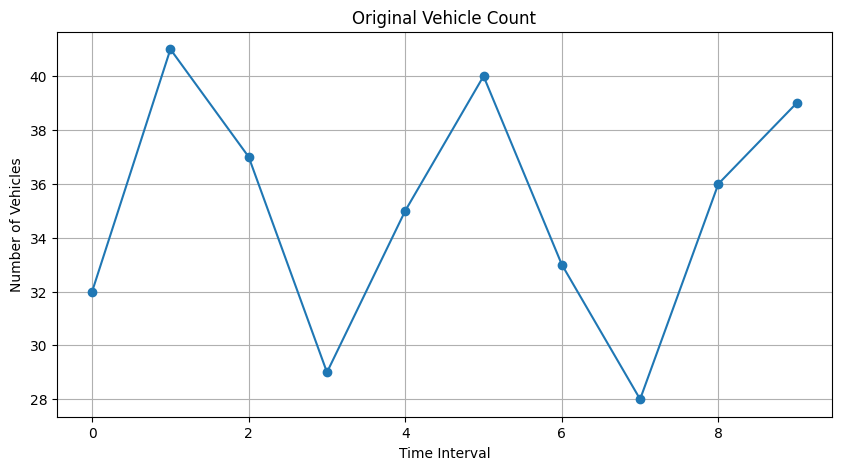

In [7]:
plt.figure(figsize=(10,5))

plt.plot(df["Vehicle Count"],marker="o")

plt.title("Original Vehicle Count")

plt.xlabel("Time Interval")

plt.ylabel("Number of Vehicles")

plt.grid(True)

plt.show()

Monte Carlo Distribution

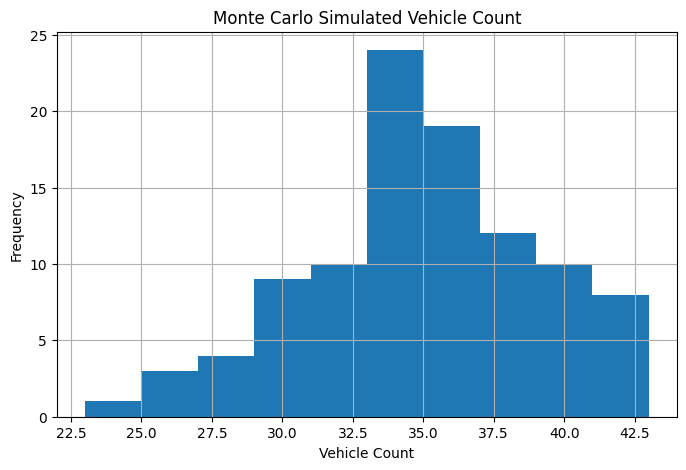

In [8]:
plt.figure(figsize=(8,5))

plt.hist(simulation,bins=10)

plt.title("Monte Carlo Simulated Vehicle Count")

plt.xlabel("Vehicle Count")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

Comparison Graph

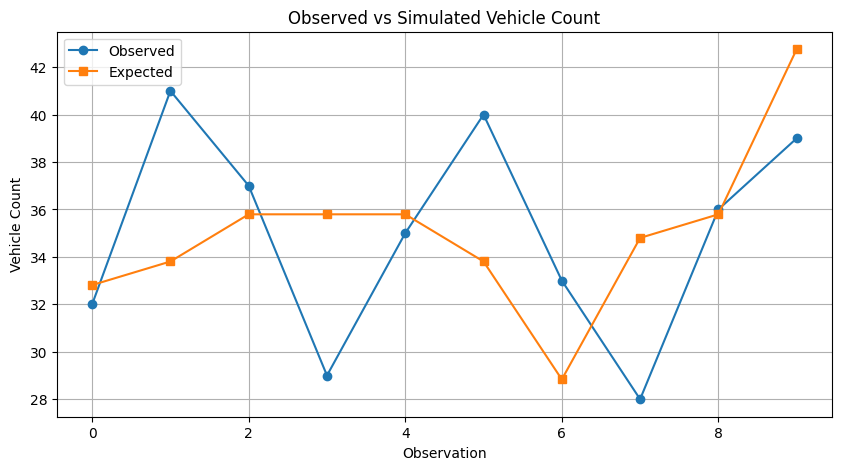

In [9]:
plt.figure(figsize=(10,5))

plt.plot(df["Vehicle Count"],label="Observed",marker="o")

plt.plot(expected,label="Expected",marker="s")

plt.legend()

plt.title("Observed vs Simulated Vehicle Count")

plt.xlabel("Observation")

plt.ylabel("Vehicle Count")

plt.grid(True)

plt.show()

Conclusion

In [10]:
print("Simulation Completed Successfully")

print("Traffic behavior analyzed.")

print("Monte Carlo simulation performed.")

print("Chi-Square validation completed.")

print("Graphs generated successfully.")

Simulation Completed Successfully
Traffic behavior analyzed.
Monte Carlo simulation performed.
Chi-Square validation completed.
Graphs generated successfully.
